# See how well the MACE-OFF models do on the DES370K dimer scans

In [5]:
from datasets import Dataset
from pathlib import Path
import pandas as pd
import torch
from openff.toolkit import ForceField, Molecule
from openff.interchange import Interchange
import descent.targets.dimers
import numpy as np
import openmm
from tqdm import tqdm
import numpy.typing as npt
from ase import Atoms
import numpy as np
import torch
from mace.calculators import mace_off, mace_omol
import matplotlib.pyplot as plt
from openff.units import unit as off_unit
from copy import deepcopy
from rdkit import Chem
import pickle as pkl
import seaborn as sns

plt.style.use("ggplot")

EV_TO_KCALMOL = 23.0605

# MACE_MODELS = ["small", "medium", "large", "extra_large", "small-omat-0"]
MACE_MODELS = ["small", "medium", "large", "extra_large"]

In [8]:
dataset_all = Dataset.load_from_disk("../dimer_datasets/DES370K_cbs_CCSD(T)_all_dataset")

## Get the the dimer scans only (no MD data)

In [9]:
orig_data = pd.read_csv("DES370K.csv")

In [10]:
orig_data["group_orig"].unique()

array(['qm_opt_dimer', 'md_solvation', 'md_dimer', 'md_nmer'],
      dtype=object)

In [11]:
sum([len(entry["energy"]) for entry in dataset_all])

269307

In [12]:
def is_dimer_scan(row):
    group_id = int(row["source"].split(" ")[-1].split("=")[1])
    # Get the row from the original data
    orig_data_row = orig_data[orig_data["group_id"] == group_id]
    # Now extract the group_orig
    group_origs = orig_data_row["group_orig"].values
    return all(["dimer" in group_orig for group_orig in group_origs])

In [13]:
dataset_dimer = dataset_all.filter(is_dimer_scan)

In [14]:
print(f"{len(dataset_all)=}")
print(f"{len(dataset_dimer)=}")

len(dataset_all)=8868
len(dataset_dimer)=6143


In [15]:
# Double-check that everything is neutral
def assert_is_neutral(mapped_smiles:str):
    mol = Molecule.from_mapped_smiles(mapped_smiles).to_rdkit()
    # Get the formal charge
    formal_charge = sum(atom.GetFormalCharge() for atom in mol.GetAtoms())
    assert formal_charge == 0, f"Formal charge is not zero for {mapped_smiles}"
    

for entry in tqdm(dataset_all):
    assert_is_neutral(entry["smiles_a"])
    assert_is_neutral(entry["smiles_b"])

100%|██████████| 8868/8868 [00:11<00:00, 792.89it/s] 


In [75]:
# For each dimer in the dataset, add a final set of coordinates where the dimers
# are separated by a very large distance, so we can use this as a reference zero-energy point
dataset_dimer_with_ref = deepcopy(dataset_dimer)

def add_ref_coords_and_energy(entry):
    import torch
    import numpy as np
    from copy import deepcopy
    mol_a = Molecule.from_mapped_smiles(entry["smiles_a"]).to_rdkit()
    mol_b = Molecule.from_mapped_smiles(entry["smiles_b"]).to_rdkit()
    coords = entry["coords"]

    n_atoms_a, n_atoms_b = mol_a.GetNumAtoms(), mol_b.GetNumAtoms()
    tot_atoms = n_atoms_a + n_atoms_b
    coords = coords.view(-1, tot_atoms, 3)
    coords = coords.detach().cpu().numpy()

    coords_extended = deepcopy(coords[-1])
    coords_extended[n_atoms_a:, 2] += 10000
    coords_new = np.concatenate([coords, coords_extended[np.newaxis, ...]], axis=0)
    coords_new = coords_new.reshape(-1)

    energy = entry["energy"].detach().cpu().numpy()
    energy_new = np.concatenate([energy, np.array([0.0])], axis=0)

    # Return updated fields
    entry["coords"] = torch.tensor(coords_new, dtype=torch.float32).cuda()
    entry["energy"] = torch.tensor(energy_new, dtype=torch.float32).cuda()
    return entry

dataset_dimer_with_ref = dataset_dimer_with_ref.map(add_ref_coords_and_energy)

Map:   0%|          | 0/6143 [00:00<?, ? examples/s]

In [76]:
dataset_dimer[0]["coords"].shape

torch.Size([2088])

In [77]:
dataset_dimer_with_ref[0]["coords"].shape

torch.Size([2160])

## Get the energies with Sage 2.2.1

In [48]:
ff, topologies = torch.load("../ff_and_top_files/openff_unconstrained-2.2.0_DES370K_cbs_CCSD(T)_all_dataset_ff_and_tops.pt")

/tmp/ipykernel_702572/734652033.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ff, topologies = torch.load("../ff_and_top_files/openff_unconstrained-2.2.0_DES370K_cbs_C

In [78]:
energies_sage220 = []

for dimer in tqdm(descent.utils.dataset.iter_dataset(dataset_dimer_with_ref), total=len(dataset_dimer_with_ref)):
    _, pred_energies_sage220 = descent.targets.dimers._predict(dimer, ff, topologies)
    pred_energies_sage220 = pred_energies_sage220.detach().cpu().numpy()
    pred_energies_minus_ref = (pred_energies_sage220 - pred_energies_sage220[-1])[:-1]
    energies_sage220.append(pred_energies_minus_ref)

100%|██████████| 6143/6143 [00:34<00:00, 178.39it/s]


## Functionality to evaluate energies with MACE-OFF

See `get_energies_mace.py`

In [45]:
ff = ForceField("openff_unconstrained-2.2.0.offxml")

/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/smirnoff99frosst/smirnoff99frosst.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [50]:
# Largely from https://github.com/openforcefield/openff-interchange/blob/55eb4b9054109304ea9c80581c0dbe3b981237a3/openff/interchange/drivers/openmm.py#L100C1-L140C24
# And moved to script

def get_openmm_dimer_energies(
    system: "openmm.System",
    positions: "openmm.unit.Quantity",
    platform: str,
) -> dict[int, "openmm.unit.Quantity"]:
    """Given prepared `openmm` objects, run a single-point energy calculation."""
    for index, force in enumerate(system.getForces()):
        force.setForceGroup(index)

    integrator = openmm.LangevinMiddleIntegrator(
        300 * openmm.unit.kelvin,
        1.0 / openmm.unit.picosecond,
        1.0 * openmm.unit.femtoseconds,
    )

    context = openmm.Context(
        system,
        integrator,
        openmm.Platform.getPlatformByName(platform),
    )

    context.setPositions(positions)

    raw_energies: dict[int, openmm.unit.Quantity] = dict()

    for index in range(system.getNumForces()):
        state = context.getState(getEnergy=True, groups={index})
        raw_energies[index] = state.getPotentialEnergy()
        del state

    del context
    del integrator

    return raw_energies


def to_ase(mol_a: Chem.Mol,
                  mol_b: Chem.Mol,
                  coords: npt.NDArray) -> Atoms:
    """Convert mapped SMILES + coordinates into an ASE Atoms object."""

    symbols, tags = [], []
    for mol in mol_a, mol_b:
        for atom in mol.GetAtoms():
            symbols.append(atom.GetSymbol())
            tags.append(atom.GetAtomMapNum())  # mapping numbers

    # Build ASE Atoms
    atoms = Atoms(symbols=symbols, positions=coords)
    atoms.set_tags(tags)

    # Asumme netural and closed-shell
    atoms.info["charge"] = 0.0  # neutral
    atoms.info["spin"] = 1.0  # spin multiplicity


    return atoms


def get_energy_mace(smiles_a: str,
                   smiles_b: str,
                   coords: torch.Tensor,
                   model_name: str) -> npt.NDArray:
    """Evaluate the energies for a set of dimer coordinates using MACE-OFF"""

    # Convert 
    mol_a = Molecule.from_mapped_smiles(smiles_a).to_rdkit()
    mol_b = Molecule.from_mapped_smiles(smiles_b).to_rdkit()

    # Reshape the coordinates
    n_atoms_a, n_atoms_b = mol_a.GetNumAtoms(), mol_b.GetNumAtoms()
    tot_atoms = n_atoms_a + n_atoms_b
    coords = coords.view(-1, tot_atoms, 3)
    coords = coords.detach().cpu().numpy()

    # Add a single new set of coordinates at massive separation to allow the definition
    # of 0 energy. Do this by adding 10,000 A to the second molecule z direction
    coords_extended = deepcopy(coords[-1])
    coords_extended[n_atoms_a:, 2] += 10000
    coords = np.concatenate([coords, coords_extended[np.newaxis, ...]], axis=0)

    # Get the MACE calculator
    calc = mace_omol(model=model_name, device='cuda') if model_name == "extra_large" else mace_off(model=model_name, device='cuda')

    # Get the energies
    energies = np.zeros(coords.shape[0])
    for i, coord in enumerate(coords):
        atoms = to_ase(mol_a, mol_b, coord)
        atoms.calc = calc
        energies[i] = atoms.get_potential_energy() * EV_TO_KCALMOL

    return energies

def get_shortest_distance(smiles_a : str, smiles_b : str, coords: torch.Tensor) -> npt.NDArray:
    """Get the shortest distances between any two atoms over the full dimer scan"""

    # Convert 
    mol_a = Molecule.from_mapped_smiles(smiles_a).to_rdkit()
    mol_b = Molecule.from_mapped_smiles(smiles_b).to_rdkit()

    # Reshape the coordinates
    n_atoms_a, n_atoms_b = mol_a.GetNumAtoms(), mol_b.GetNumAtoms()
    tot_atoms = n_atoms_a + n_atoms_b
    coords = coords.view(-1, tot_atoms, 3)
    coords = coords.detach().cpu().numpy()

    # Compute the shortest distances
    dists = np.zeros(coords.shape[0])
    for i, coord in enumerate(coords):
        coord_mol_a = coord[:n_atoms_a, :]
        coord_mol_b = coord[n_atoms_a:, :]
        dists[i] = np.min(np.linalg.norm(coord_mol_a[:, np.newaxis] - coord_mol_b[np.newaxis, :, :], axis=-1))

    return dists


In [12]:
calc = mace_omol(model="extra_large", device='cuda')

/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

Using float64 for MACECalculator, recommended for geometry optimization.
Using head omol out of ['omol']


In [13]:
calc.models[1]

IndexError: list index out of range

In [ ]:
calc.models

[ScaleShiftMACE(
   (node_embedding): LinearNodeEmbeddingBlock(
     (linear): Linear(83x0e -> 1024x0e | 84992 weights)
   )
   (joint_embedding): GenericJointEmbedding(
     (embedders): ModuleDict(
       (total_spin): Embedding(101, 1024)
       (total_charge): Embedding(201, 1024)
     )
     (project): Sequential(
       (0): Linear(in_features=2048, out_features=1024, bias=False)
       (1): SiLU()
     )
   )
   (embedding_readout): LinearReadoutBlock(
     (linear): Linear(1024x0e -> 1x0e | 1024 weights)
   )
   (radial_embedding): RadialEmbeddingBlock(
     (bessel_fn): BesselBasis(r_max=6.0, num_basis=8, trainable=False)
     (cutoff_fn): PolynomialCutoff(p=5, r_max=6.0)
   )
   (spherical_harmonics): SphericalHarmonics()
   (atomic_energies_fn): AtomicEnergiesBlock(energies=[[-16.0024, -81.7823, -201.7423, -392.8672, -678.7072, -1037.0938, -1490.4038, -2047.7086, -2717.3896, -3511.7048, -4412.5273, -5442.3691, -6589.6270, -7880.8745, -9290.2979, -10834.8213, -12522.3174, -14

Using float64 for MACECalculator, recommended for geometry optimization.


/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

Using head omol out of ['omol']


/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/matscipy/neighbours.py:718: RuntimeWarning: Ratio of simulation cell size to cutoff is very large; reducing number of bins for neighbour list search, but this may be slow. Are you using a cell with lots of vacuum?
  return ffi.neighbour_list(quantities, cell_origin, cell,


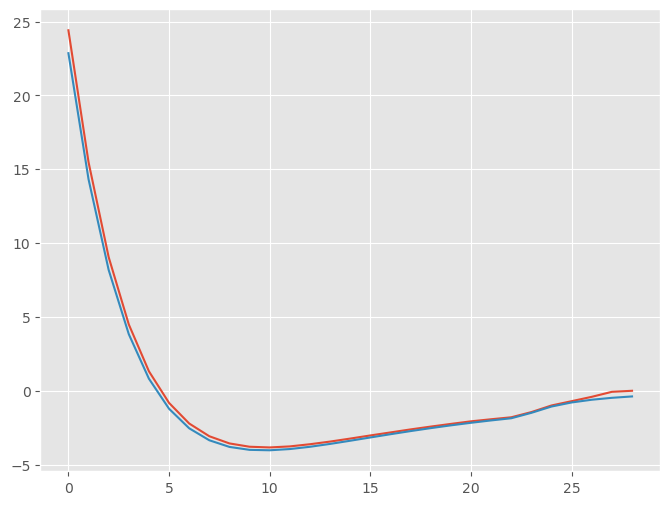

In [15]:
INDEX=400
energies = get_energy_mace(dataset_dimer[INDEX]["smiles_a"],dataset_dimer[INDEX]["smiles_b"], 
                           dataset_dimer[INDEX]["coords"], 
                           model_name="extra_large")
delta_energies = (energies - energies[-1])[:-1]  # Subtract the last energy (which is the 10,000 A separation)
true_energies = dataset_dimer[INDEX]["energy"]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(delta_energies, label="MACE-OFF (Extra Large)")
ax.plot(true_energies, label="True Energies")

In [51]:
# Load back in the calculated MACE energies
energies = {}
for model in MACE_MODELS:
    with open(f"energies_mace_{model}.pkl", "rb") as f:
        energies[model] = pkl.load(f)

In [52]:
for model in MACE_MODELS:
    dataset_dimer = dataset_dimer.add_column(name=f"energy_mace_{model}", column=[(nrg - nrg[-1])[:-1] for nrg in energies[model]])

In [53]:
# Add min distances
min_dists = [get_shortest_distance(entry["smiles_a"], entry["smiles_b"], entry["coords"]) for entry in tqdm(dataset_dimer)]
dataset_dimer = dataset_dimer.add_column("min_distance", min_dists)

100%|██████████| 6143/6143 [00:10<00:00, 582.49it/s]


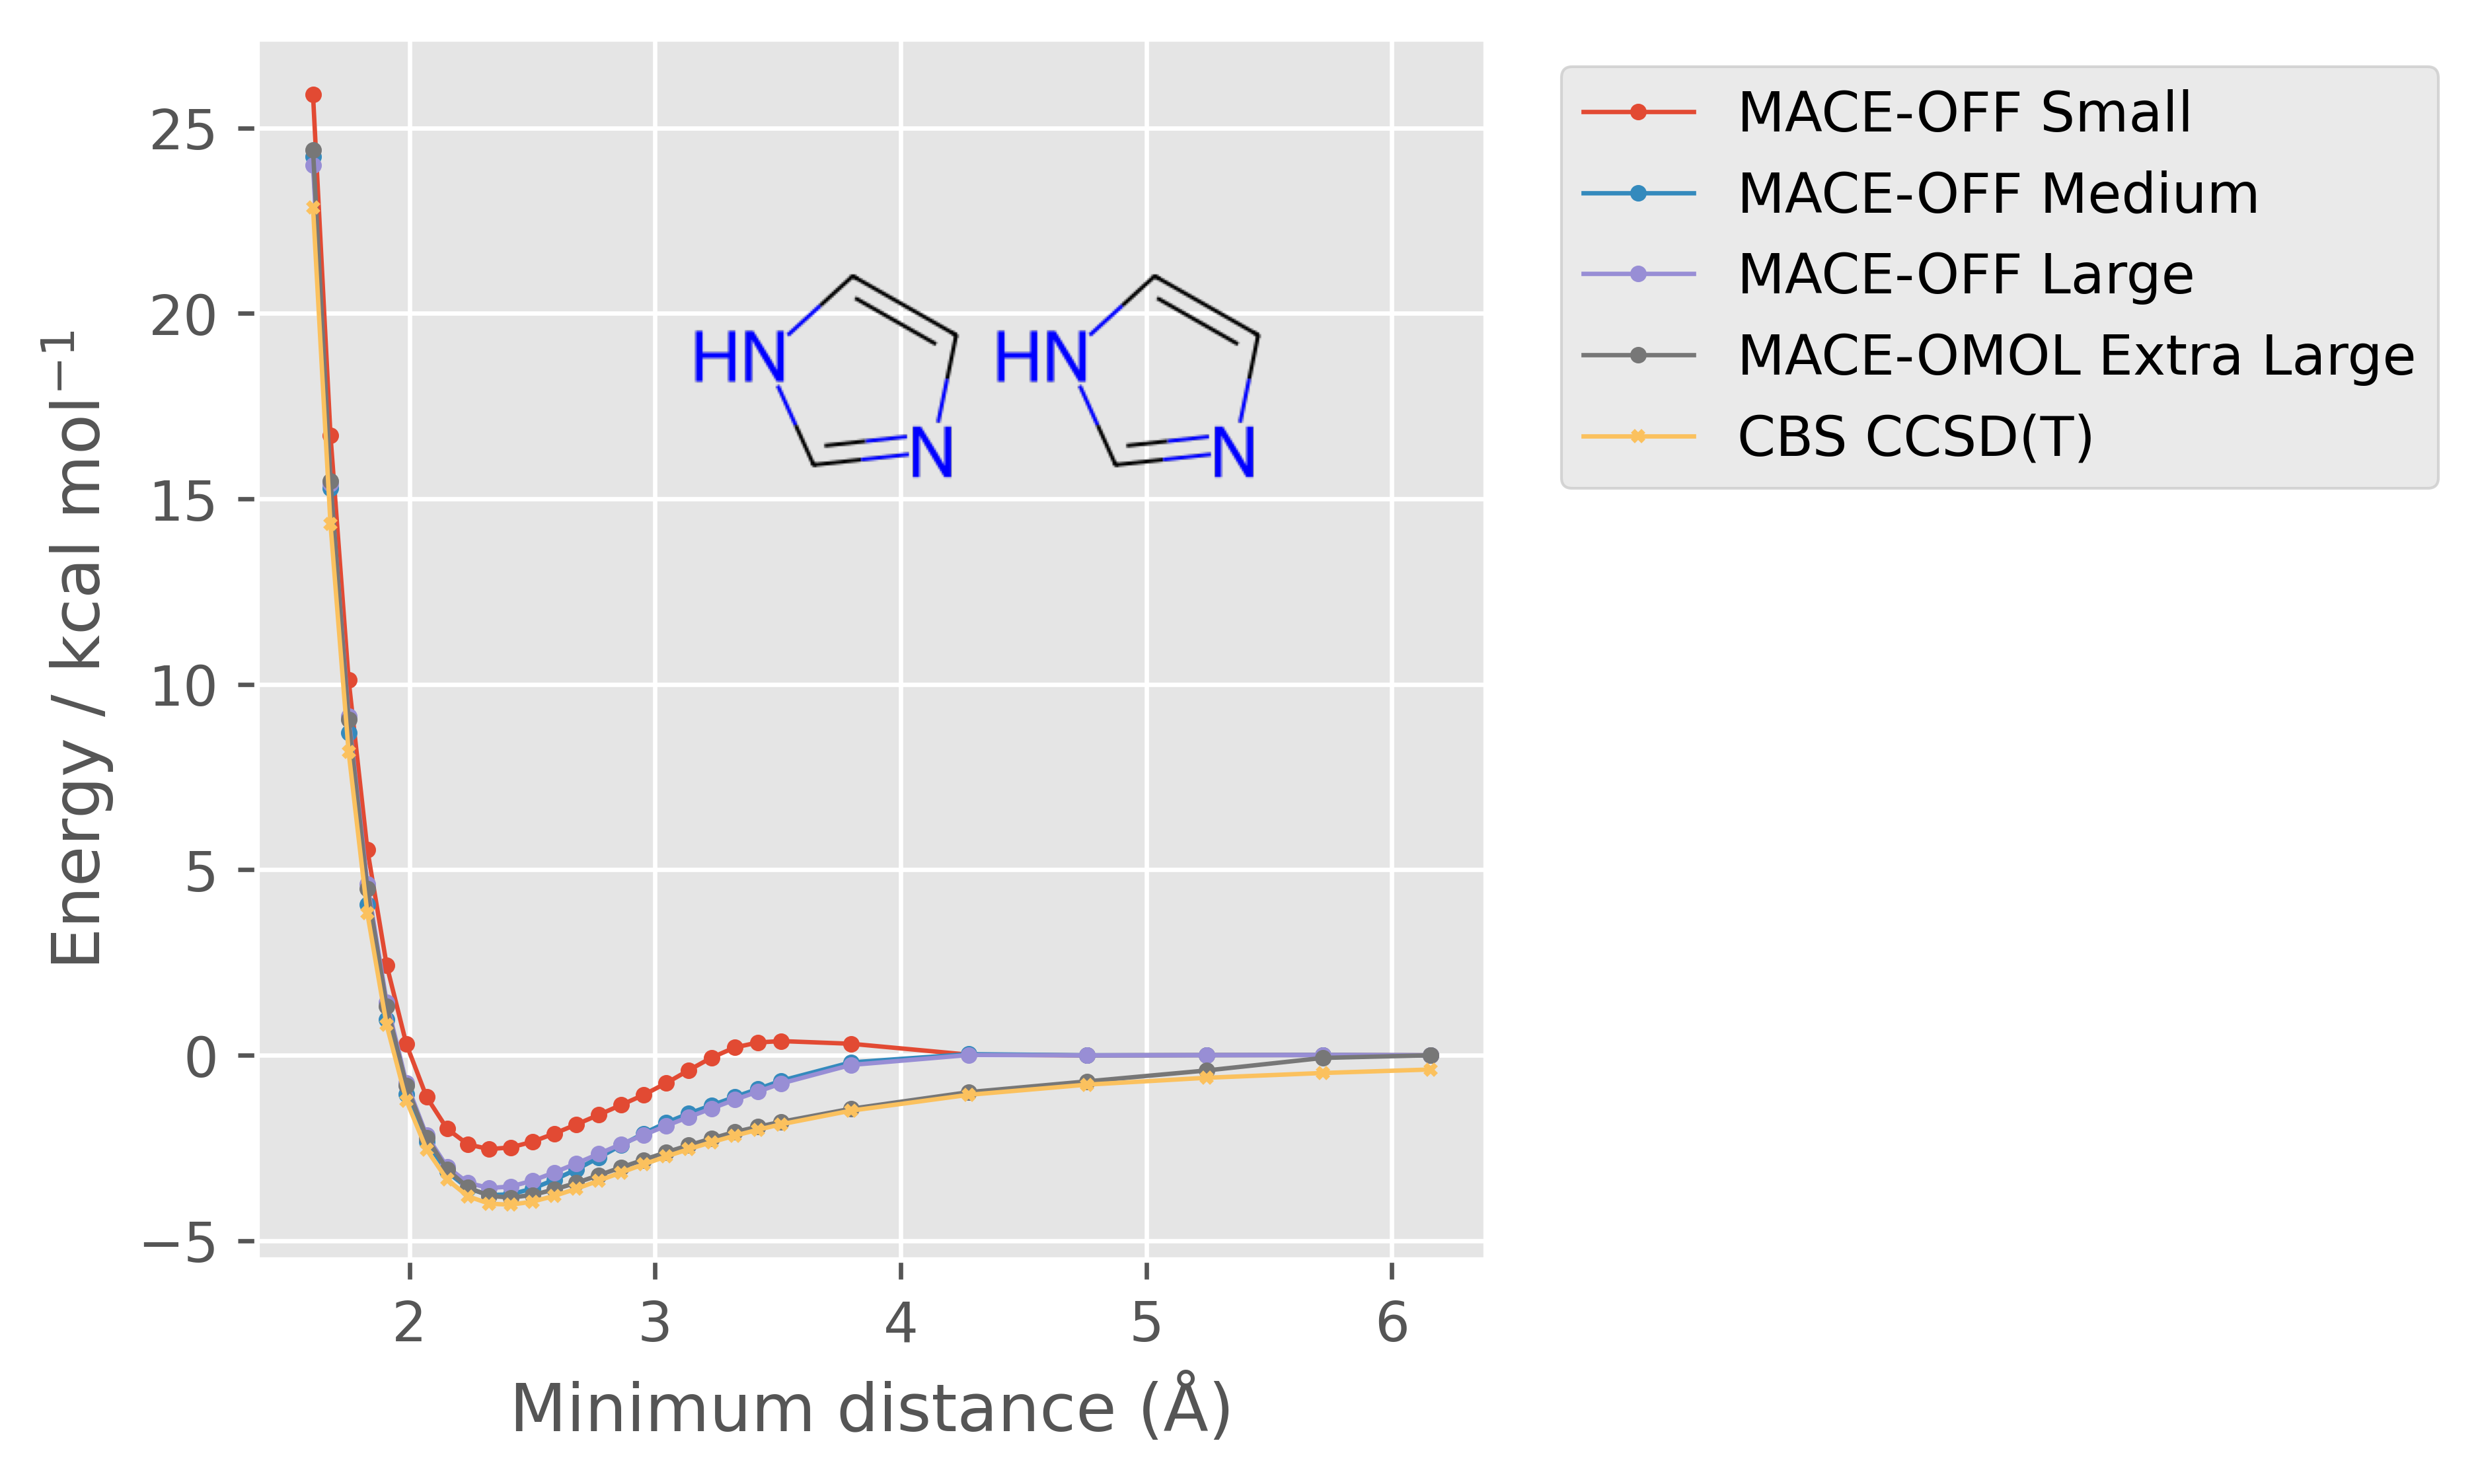

In [154]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
import io
from PIL import Image

def mol_to_img(mol, size=(150,150), kekulize=True):
    """Convert RDKit mol to transparent PIL image without atom indices."""
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    opts = drawer.drawOptions()
    opts.clearBackground = False      # transparent background
    opts.addAtomIndices = False       # turn OFF atom index labels
    # keep atom labels (default = True), so O, N, etc. are shown
    if kekulize:
        Chem.Kekulize(mol, clearAromaticFlags=True)
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
    drawer.FinishDrawing()
    png = drawer.GetDrawingText()
    return Image.open(io.BytesIO(png))


def add_inset_image(ax, image, xy, zoom=0.25):
    """Helper to add a PIL image at a given location."""
    im = OffsetImage(image, zoom=zoom)
    ab = AnnotationBbox(im, xy, frameon=False)
    ax.add_artist(ab)

INDEX = 400
fig, ax = plt.subplots(figsize=(4, 4), dpi=600)
# ax.set_ylim(-5, 5)


# Plot MACE models
for model in MACE_MODELS:
    label = f"MACE-OFF {model.capitalize()}" if model != "extra_large" else "MACE-OMOL Extra Large"
    ax.plot(dataset_dimer[INDEX]["min_distance"],
            dataset_dimer[INDEX][f"energy_mace_{model}"],
            label=label, marker="o", markersize=2, linewidth=0.8)

# Sage 2.2.0
# ax.plot(dataset_dimer[INDEX]["min_distance"],
#         energies_sage220[INDEX],
#         label="OFF Sage 2.2.0 - TIP3P", marker="^", markersize=2, linewidth=0.8)

# Reference
ax.plot(dataset_dimer[INDEX]["min_distance"],
        dataset_dimer[INDEX]["energy"],
        label="CBS CCSD(T)", marker="x", markersize=2, linewidth=0.8)


# Generate transparent mol images without labels
smiles_a = dataset_dimer[INDEX]["smiles_a"]
smiles_b = dataset_dimer[INDEX]["smiles_b"]
mol_a = Chem.MolFromSmiles(smiles_a)
mol_b = Chem.MolFromSmiles(smiles_b)
# Remove atom index labels
for atom in mol_a.GetAtoms():
    atom.SetAtomMapNum(0)
for atom in mol_b.GetAtoms():
    atom.SetAtomMapNum(0)
img_a = mol_to_img(mol_a)
img_b = mol_to_img(mol_b)

# Place them on the plot
add_inset_image(ax, img_a,
                xy=(max(dataset_dimer[INDEX]["min_distance"])*0.6,
                    max(dataset_dimer[INDEX]["energy"])*0.8),
                zoom=0.35)
add_inset_image(ax, img_b,
                xy=(max(dataset_dimer[INDEX]["min_distance"])*0.8,
                    max(dataset_dimer[INDEX]["energy"])*0.8),
                zoom=0.35)

ax.set_ylabel("Energy / kcal mol$^{-1}$")
ax.set_xlabel("Minimum distance (Å)")

fig.legend(loc="upper left", bbox_to_anchor=(0.93, 0.88))

plt.show()


[C:1]([C:2]([C:3](=[O:4])[N:5]([C:6]([H:13])([H:14])[H:15])[H:12])([H:10])[H:11])([H:7])([H:8])[H:9] [O:1]([H:2])[H:3]


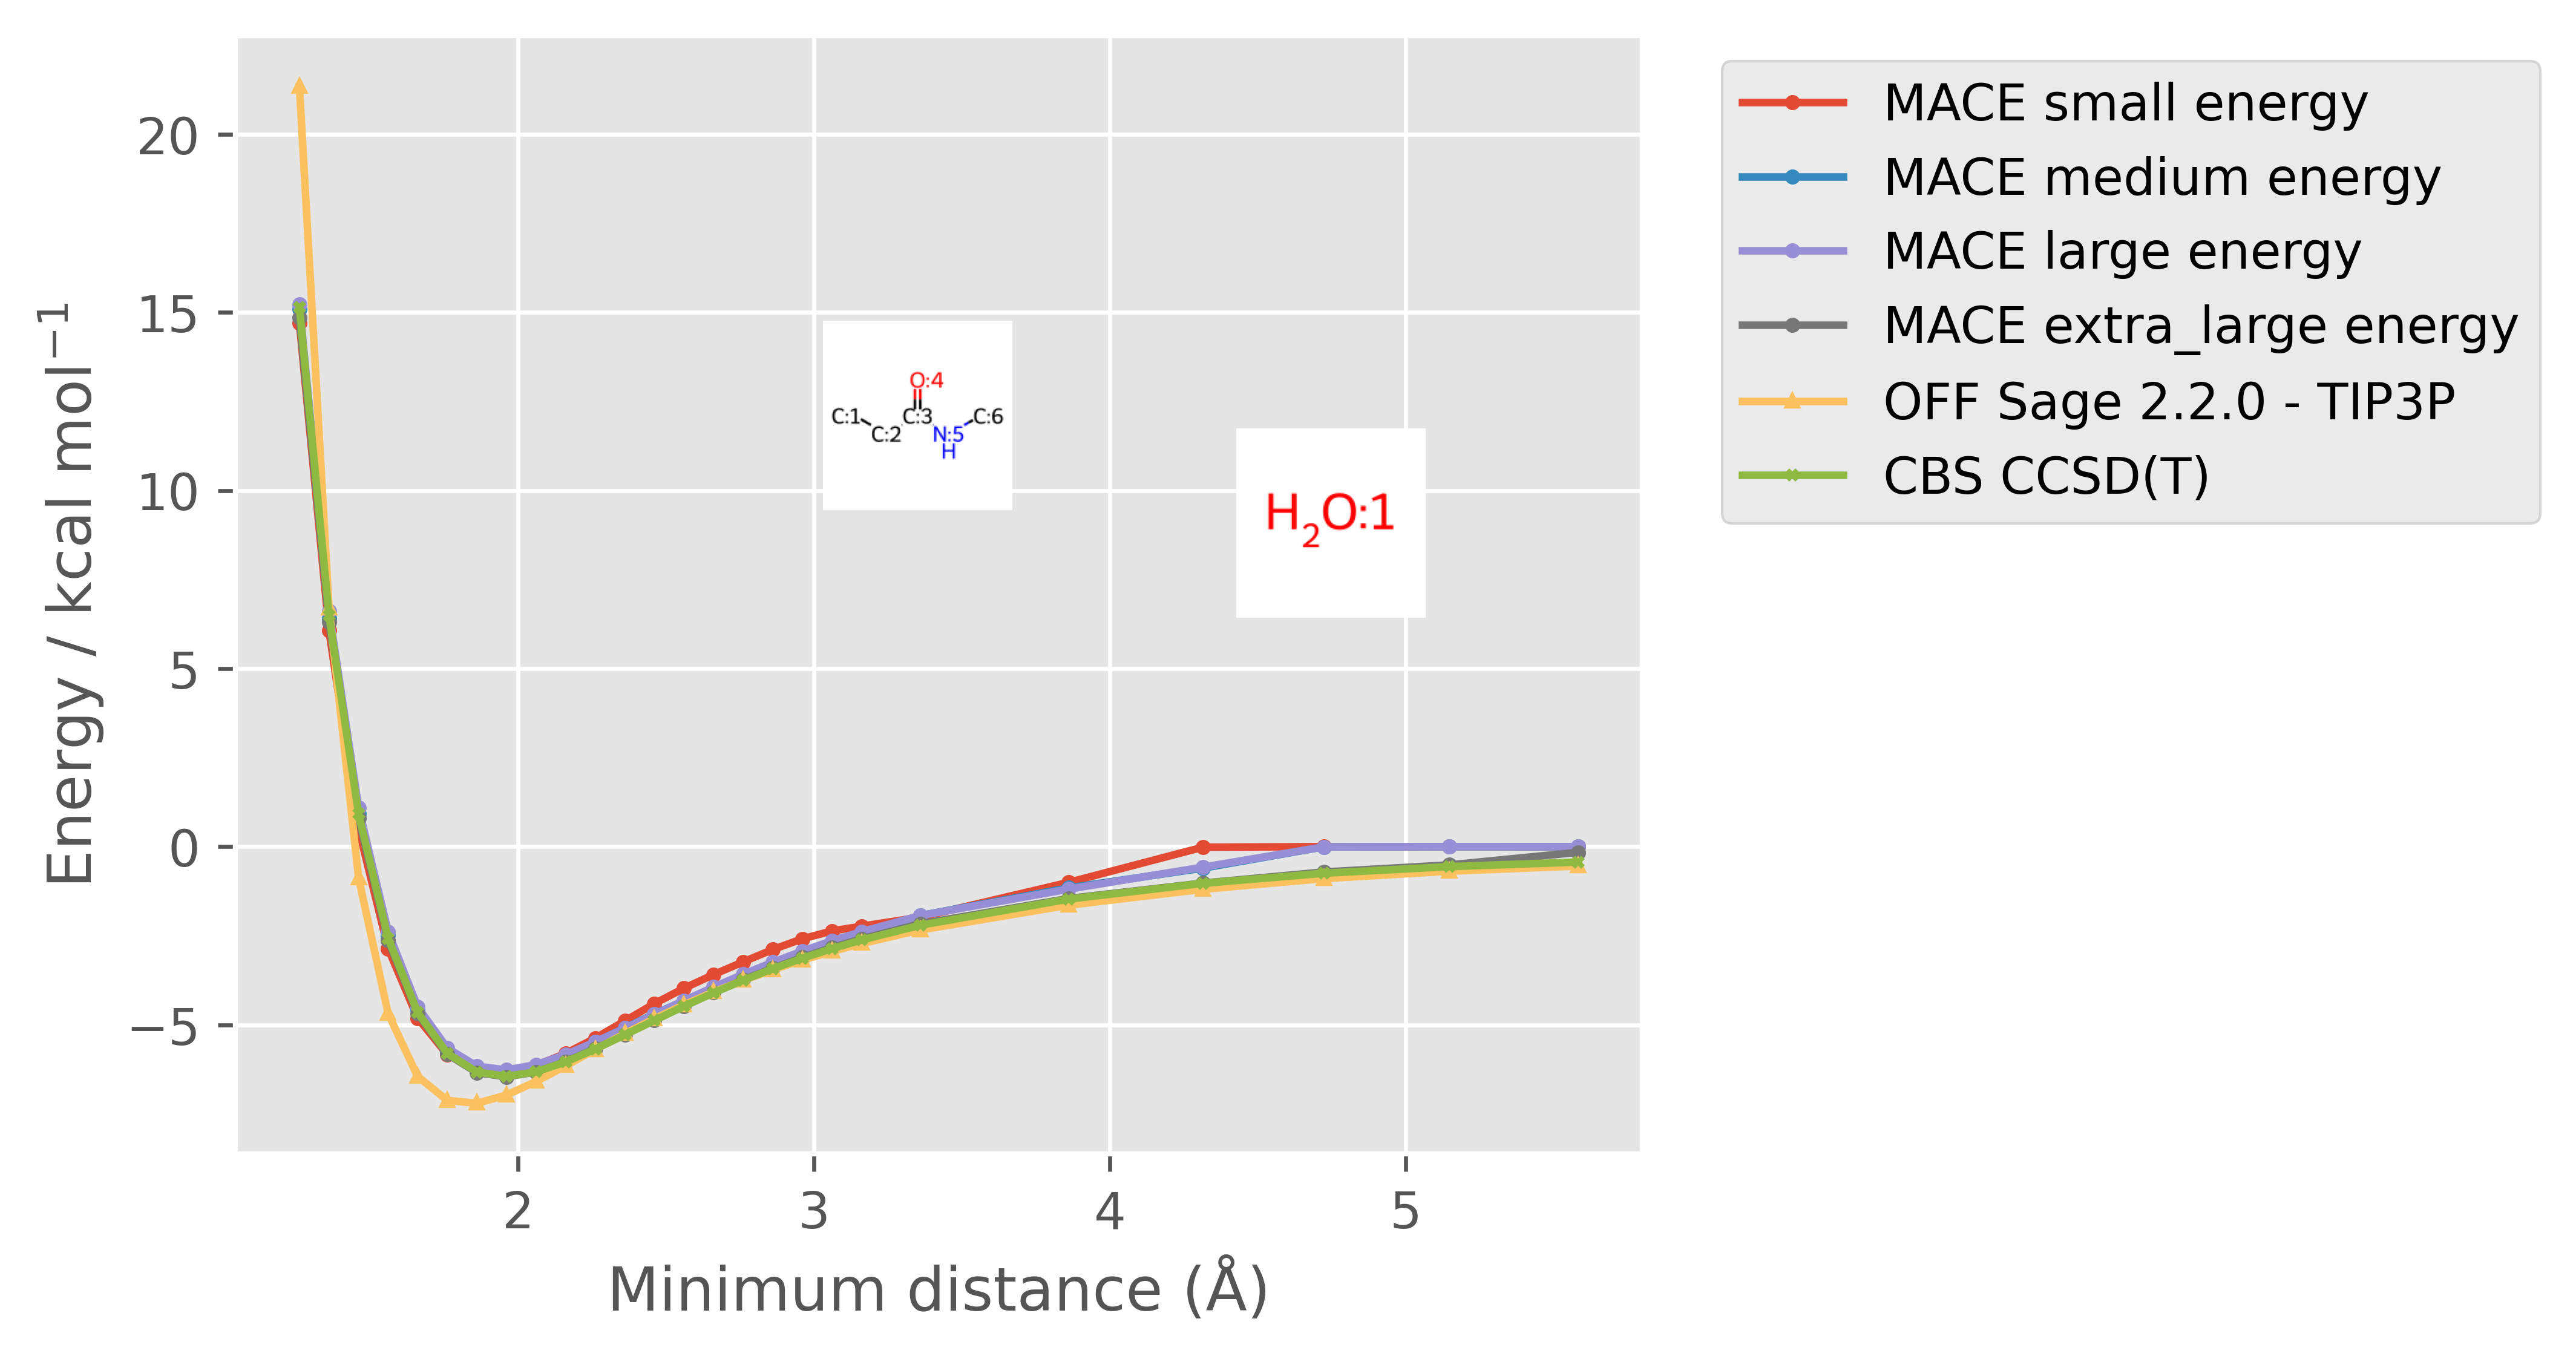

In [101]:
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt

# Add the energies to the dataset
INDEX = 2500

fig, ax = plt.subplots(figsize=(5, 4), dpi=600)

# Plot all the energies and MACE energies
dists = get_shortest_distance(dataset_dimer[INDEX]["smiles_a"], 
                              dataset_dimer[INDEX]["smiles_b"], 
                              dataset_dimer[INDEX]["coords"])
for model in MACE_MODELS:
    label = f"MACE-OFF {model}" if model != "extra_large" else "MACE-OMOL Extra Large"
    ax.plot(dataset_dimer[INDEX]["min_distance"], 
            dataset_dimer[INDEX][f"energy_mace_{model}"], 
            label=f"MACE {model} energy", marker="o", markersize=2)

# Sage 2.2.0
ax.plot(dataset_dimer[INDEX]["min_distance"], 
        energies_sage220[INDEX], 
        label="OFF Sage 2.2.0 - TIP3P", marker="^", markersize=2)

# Reference energies
ax.plot(dataset_dimer[INDEX]["min_distance"], 
        dataset_dimer[INDEX]["energy"], 
        label="CBS CCSD(T)", marker="x", markersize=2)

# Make RDKit mol images
smiles_a = dataset_dimer[INDEX]["smiles_a"]
smiles_b = dataset_dimer[INDEX]["smiles_b"]
mol_a = Chem.MolFromSmiles(smiles_a)
mol_b = Chem.MolFromSmiles(smiles_b)

img_a = Draw.MolToImage(mol_a, size=(150, 150))
img_b = Draw.MolToImage(mol_b, size=(150, 150))

def add_inset_image(ax, image, xy, zoom=0.25):
    """Helper to add a PIL image at a given location."""
    im = OffsetImage(image, zoom=zoom)
    ab = AnnotationBbox(im, xy, frameon=False)
    ax.add_artist(ab)

# Add the molecule structures to the plot (pick coordinates outside the curve area)
add_inset_image(ax, img_a, xy=(max(dataset_dimer[INDEX]["min_distance"])*0.6, 
                               max(dataset_dimer[INDEX]["energy"])*0.8))
add_inset_image(ax, img_b, xy=(max(dataset_dimer[INDEX]["min_distance"])*0.85, 
                               max(dataset_dimer[INDEX]["energy"])*0.6))

ax.set_ylabel("Energy / kcal mol$^{-1}$")
ax.set_xlabel("Minimum distance (Å)")

# Legend off to the side
fig.legend(
    loc="upper left",
    bbox_to_anchor=(0.93, 0.88),
)

print(smiles_a, smiles_b)
plt.show()

[C:1]([C:2]([C:3](=[O:4])[N:5]([C:6]([H:13])([H:14])[H:15])[H:12])([H:10])[H:11])([H:7])([H:8])[H:9] [O:1]([H:2])[H:3]


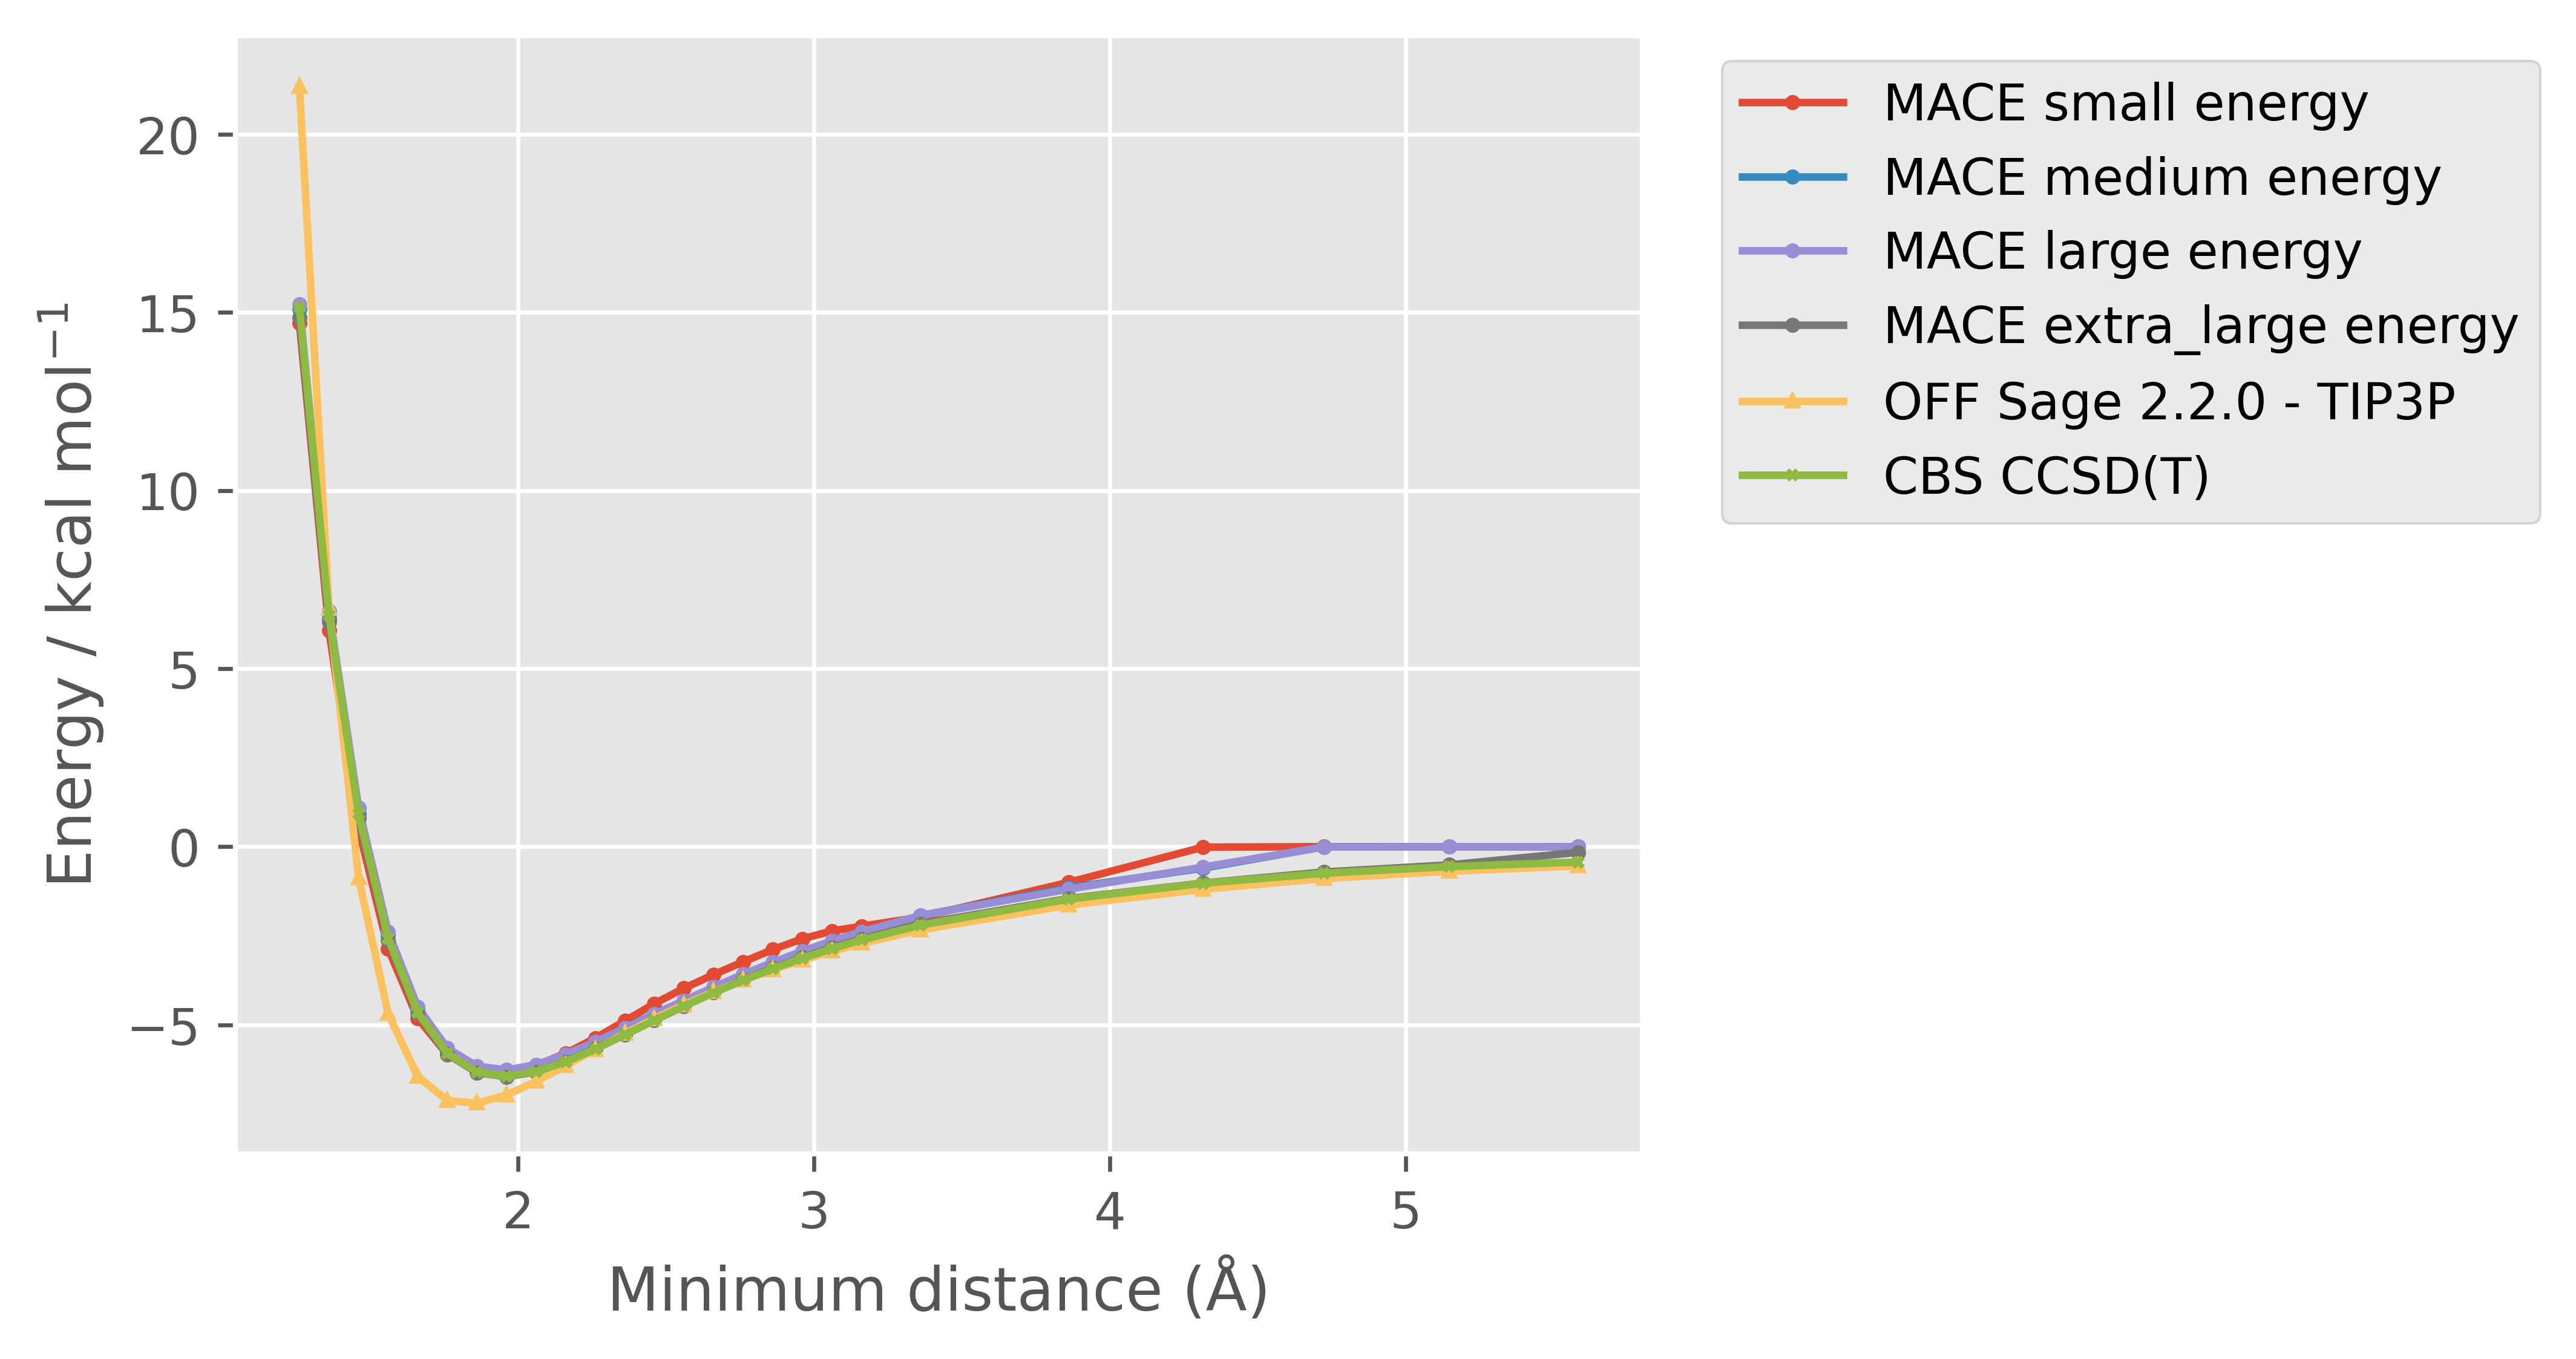

In [100]:
# Add the energies to the dataset
INDEX = 2500
# INDEX = 400
# INDEX = 0

# Plot all the energies and MACE energies

fig, ax = plt.subplots(figsize=(5, 4), dpi=600)
dists = get_shortest_distance(dataset_dimer[INDEX]["smiles_a"], dataset_dimer[INDEX]["smiles_b"], dataset_dimer[INDEX]["coords"])
for model in MACE_MODELS:
    label = f"MACE-OFF {model}" if model != "extra_large" else "MACE-OMOL Extra Large"
    ax.plot(dataset_dimer[INDEX]["min_distance"], dataset_dimer[INDEX][f"energy_mace_{model}"], label=f"MACE {model} energy", marker="o", markersize=2)

# Also plot the Sage 2.2.0 energies
ax.plot(dataset_dimer[INDEX]["min_distance"], energies_sage220[INDEX], label="OFF Sage 2.2.0 - TIP3P", marker="^", markersize=2)

ax.plot(dataset_dimer[INDEX]["min_distance"], dataset_dimer[INDEX]["energy"], label="CBS CCSD(T)", marker="x", markersize=2)

# large_energies = get_energy_mace(dataset_dimer[INDEX]["smiles_a"],dataset_dimer[INDEX]["smiles_b"], 
#                            dataset_dimer[INDEX]["coords"], 
#                            model_name="extra_large")

# large_energies = (large_energies - large_energies[-1])[:-1]  # Subtract the last energy (which is the 10,000 A separation)

# ax.plot(dataset_dimer[INDEX]["min_distance"], large_energies, label="OMOL (Extra Large)", marker="o", markersize=2)

print(dataset_dimer[INDEX]["smiles_a"], dataset_dimer[INDEX]["smiles_b"])

ax.set_ylabel("Energy / kcal mol$^{-1}$")
ax.set_xlabel("Minimum distance (Å)")
# ax.set_ylim(-2,2)
# Legend off to the side
fig.legend(
    loc="upper left",
    bbox_to_anchor=(0.93, 0.88),
    # fontsize='small'
)


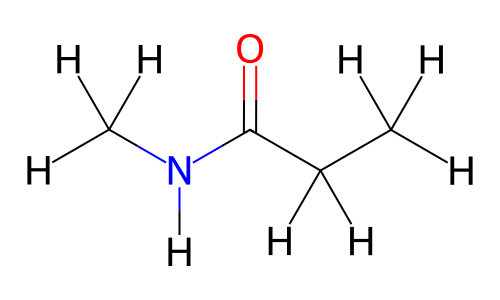

In [82]:
Molecule.from_mapped_smiles(dataset_dimer[INDEX]["smiles_a"])


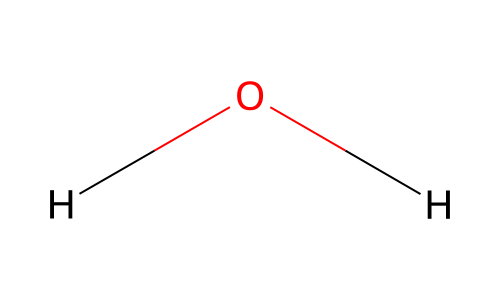

In [83]:
Molecule.from_mapped_smiles(dataset_dimer[INDEX]["smiles_b"])

/tmp/ipykernel_653877/39263885.py:1: AtomMappingWarning: Warning! Fully mapped SMILES pattern passed to `from_smiles`. The atom map is stored as a property in `Molecule._properties`, but these indices are NOT used to determine atom ordering. To use these indices for atom ordering, use `Molecule.from_mapped_smiles`.
  Molecule.from_smiles("[O:1]([C:2]1([H:9])[C:3]([H:10])([H:11])[C:4]([H:12])([H:13])[C:5]([H:14])([H:15])[C:6]([H:16])([H:17])[C:7]1([H:18])[H:19])[H:8]")


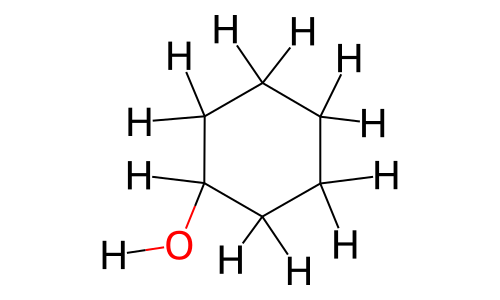

In [48]:
Molecule.from_smiles("[O:1]([C:2]1([H:9])[C:3]([H:10])([H:11])[C:4]([H:12])([H:13])[C:5]([H:14])([H:15])[C:6]([H:16])([H:17])[C:7]1([H:18])[H:19])[H:8]")

## Calculate/ plot overall statistics

In [158]:
# Get the MAE and RMSE for each model
maes = {}
rmses = {}
differences = {}
ref_energies = np.array([e for e_list in dataset_dimer["energy"] for e in e_list])

for model in MACE_MODELS:
    model_energies = np.array([e for e_list in dataset_dimer[f"energy_mace_{model}"] for e in e_list])
    diffs = model_energies - ref_energies
    differences[model] = diffs
    mae = np.mean(np.abs(diffs))
    rmse = np.sqrt(np.mean((diffs) ** 2))
    maes[model] = mae
    rmses[model] = rmse
    print(f"MACE {model} MAE: {mae:.3f} kcal/mol")
    print(f"MACE {model} RMSE: {rmse:.3f} kcal/mol")

# Also add the Sage 2.2.0 results
sage_model_energies = np.array([e for e_list in energies_sage220 for e in e_list])
sage_diffs = sage_model_energies - ref_energies
sage_mae = np.mean(np.abs(sage_diffs))
sage_rmse = np.sqrt(np.mean((sage_diffs) ** 2))
print(f"Sage 2.2.0 MAE: {sage_mae:.3f} kcal/mol")
print(f"Sage 2.2.0 RMSE: {sage_rmse:.3f} kcal/mol")


# Also compute statistics only on reference energies < 10 kJ /mol
THRESHOLD = 2.39006 # 10 kJ / mol in kcal / mol
maes_threshold = {}
rmses_threshold = {}

for model in MACE_MODELS:
    diffs = differences[model]
    mask = ref_energies < THRESHOLD
    maes_threshold[model] = np.mean(np.abs(diffs[mask]))
    rmses_threshold[model] = np.sqrt(np.mean((diffs[mask]) ** 2))
    print(f"MACE {model} MAE (threshold): {maes_threshold[model]:.3f} kcal/mol")
    print(f"MACE {model} RMSE (threshold): {rmses_threshold[model]:.3f} kcal/mol")


# Also compute for Sage 2.2.0
mask = ref_energies < THRESHOLD
sage_mae_threshold = np.mean(np.abs(sage_diffs[mask]))
sage_rmse_threshold = np.sqrt(np.mean((sage_diffs[mask]) ** 2))
print(f"Sage 2.2.0 MAE (threshold): {sage_mae_threshold:.3f} kcal/mol")
print(f"Sage 2.2.0 RMSE (threshold): {sage_rmse_threshold:.3f} kcal/mol")


MACE small MAE: 0.416 kcal/mol
MACE small RMSE: 0.620 kcal/mol
MACE medium MAE: 0.279 kcal/mol
MACE medium RMSE: 0.434 kcal/mol
MACE large MAE: 0.267 kcal/mol
MACE large RMSE: 0.401 kcal/mol
MACE extra_large MAE: 0.178 kcal/mol
MACE extra_large RMSE: 0.310 kcal/mol
Sage 2.2.0 MAE: 42.526 kcal/mol
Sage 2.2.0 RMSE: 1087.434 kcal/mol
MACE small MAE (threshold): 0.342 kcal/mol
MACE small RMSE (threshold): 0.477 kcal/mol
MACE medium MAE (threshold): 0.214 kcal/mol
MACE medium RMSE (threshold): 0.300 kcal/mol
MACE large MAE (threshold): 0.215 kcal/mol
MACE large RMSE (threshold): 0.303 kcal/mol
MACE extra_large MAE (threshold): 0.106 kcal/mol
MACE extra_large RMSE (threshold): 0.160 kcal/mol
Sage 2.2.0 MAE (threshold): 0.857 kcal/mol
Sage 2.2.0 RMSE (threshold): 4.832 kcal/mol


In [35]:
0.239006 * 1.1

0.2629066

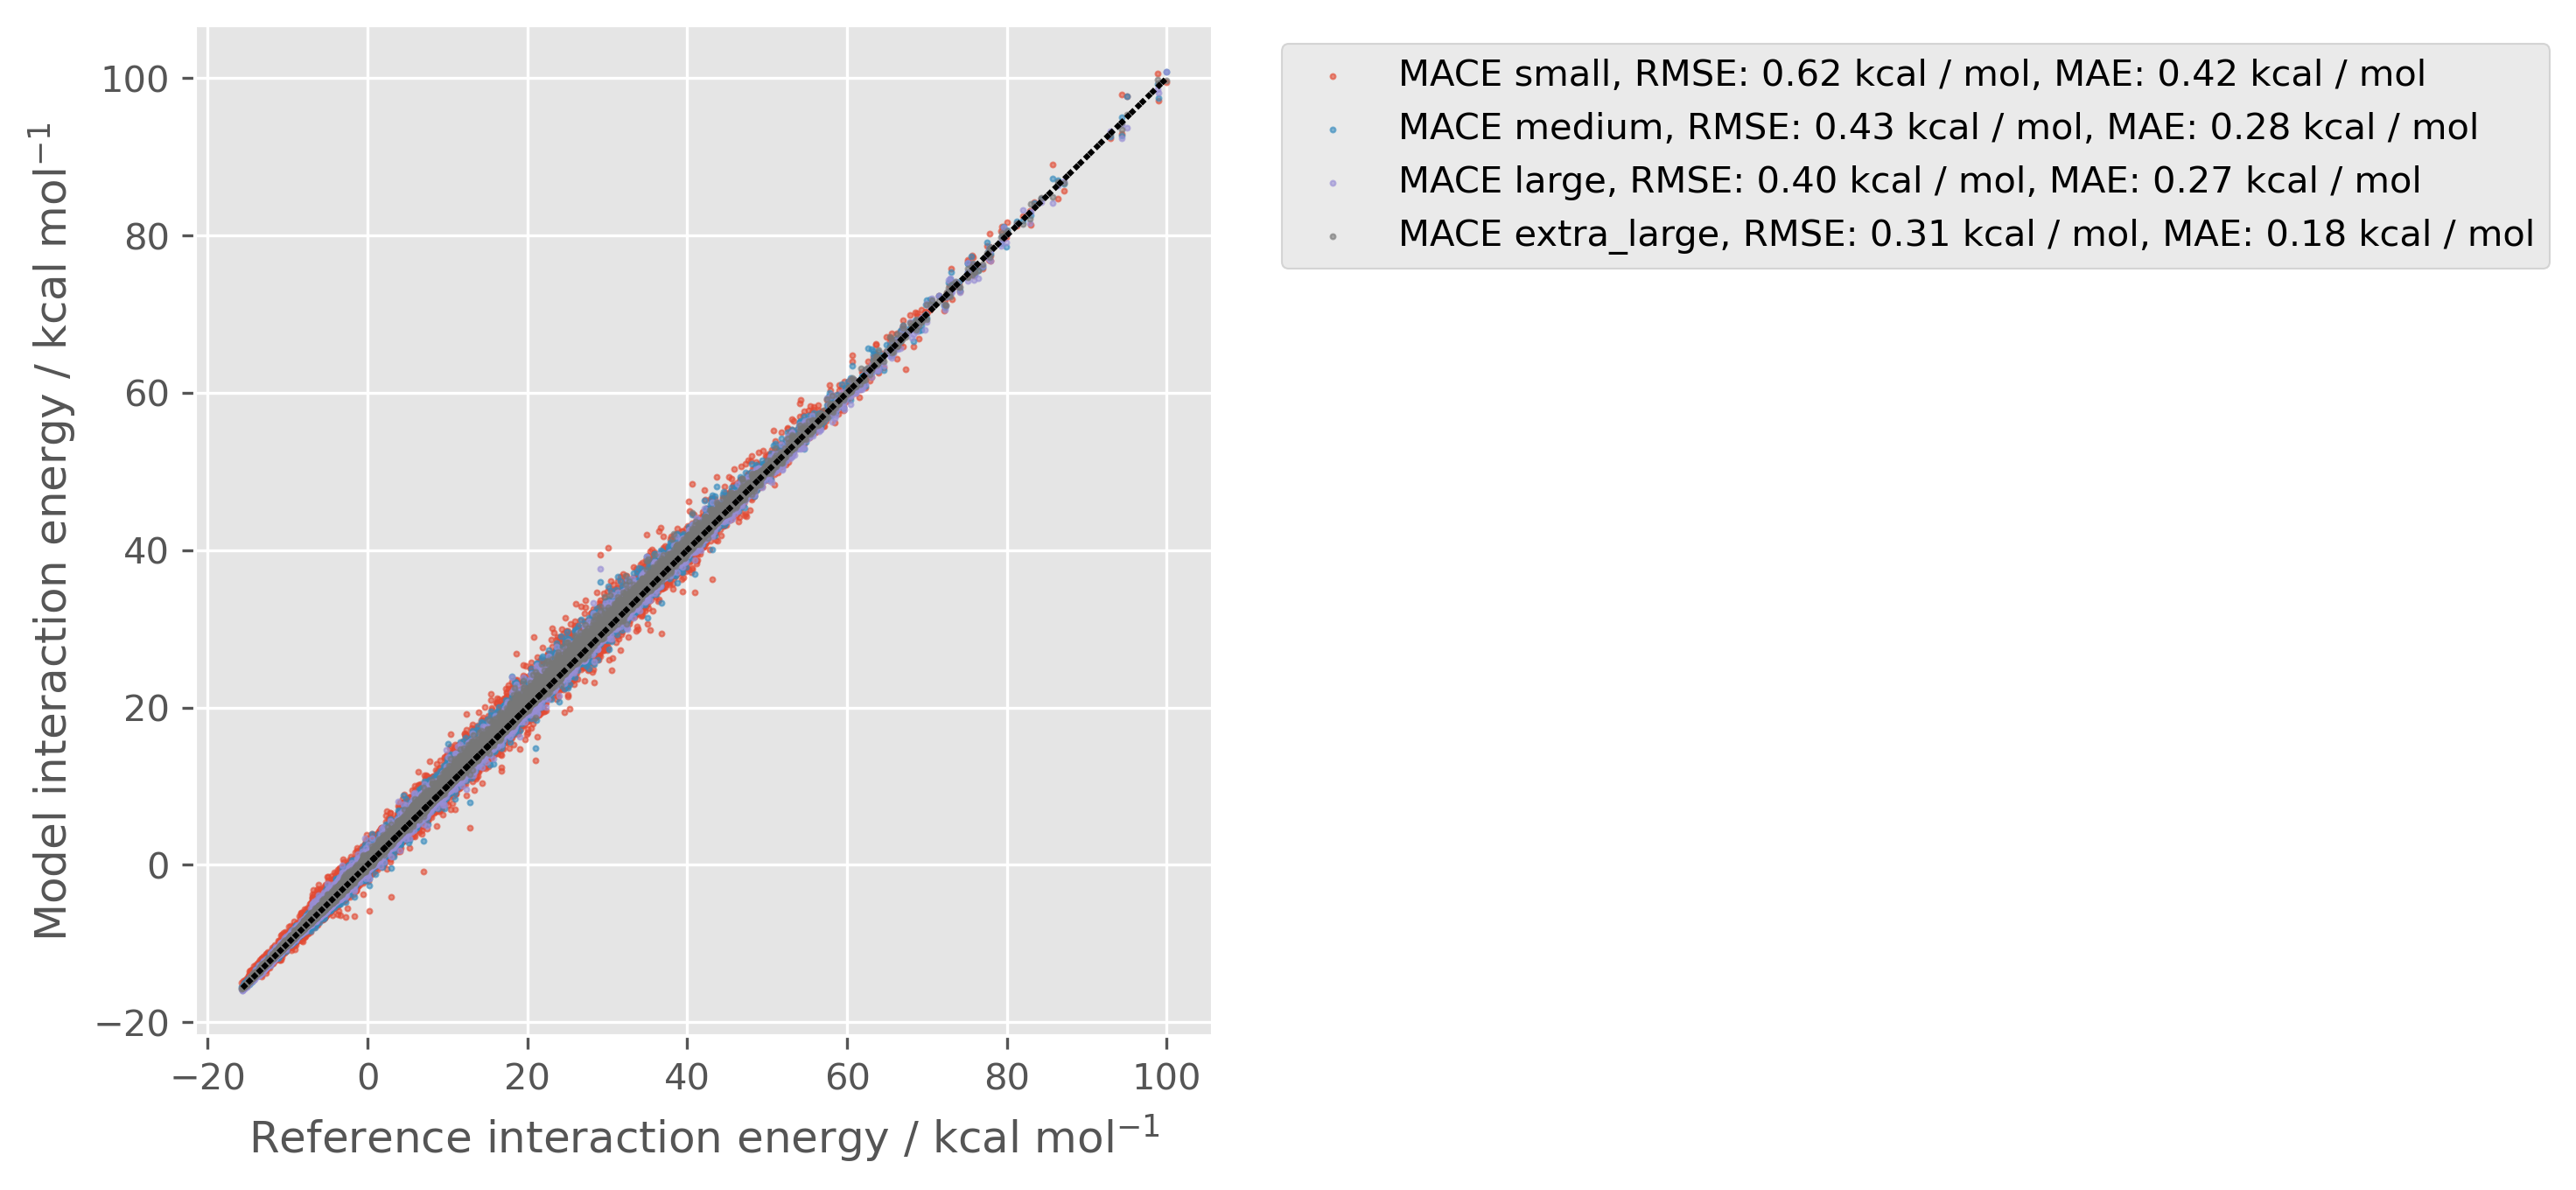

In [161]:
# Plot scatter plot of energies vs reference energy
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

# Plot Sage 2.2.0
# ax.scatter(ref_energies, sage_model_energies, label=f"Sage 2.2.0, RMSE: {sage_rmse:.2f} kcal / mol, MAE: {sage_mae:.2f} kcal / mol", alpha=0.6, marker="^", s=2)

for model in MACE_MODELS:
    model_energies = np.array([e for e_list in dataset_dimer[f"energy_mace_{model}"] for e in e_list])
    label = f"MACE {model}, RMSE: {rmses[model]:.2f} kcal / mol, MAE: {maes[model]:.2f} kcal / mol"
    ax.scatter(ref_energies, model_energies, label=label, alpha=0.6, marker="o", s=2)

# Line at x = y
ax.plot(ref_energies, ref_energies, color="k", linestyle=":")
ax.set_xlabel("Reference interaction energy / kcal mol$^{-1}$")
ax.set_ylabel("Model interaction energy / kcal mol$^{-1}$")

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

fig.savefig("mace_off_scatter_plot.png", bbox_inches="tight", dpi=300)

/tmp/ipykernel_653877/1114580596.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MACE_MODELS)


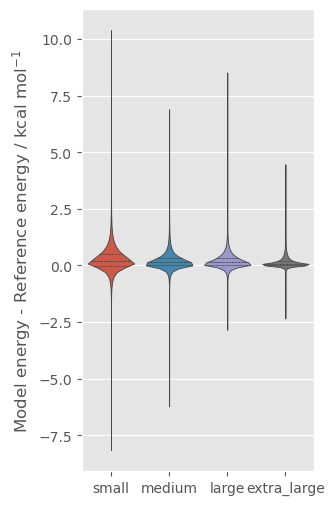

In [43]:
# Plot the violin plots of the differences
fig, ax = plt.subplots(figsize=(3, 6))
sns.violinplot(data=[differences[model] for model in MACE_MODELS], ax=ax, inner="quartile")
ax.set_xticklabels(MACE_MODELS)
ax.set_ylabel("Model energy - Reference energy / kcal mol$^{-1}$")
fig.savefig("mace_off_violin_plot.png", bbox_inches="tight", dpi=300)

/tmp/ipykernel_653877/392355120.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MACE_MODELS)


Text(0, 0.5, 'Model energy - Reference energy / kcal mol$^{-1}$')

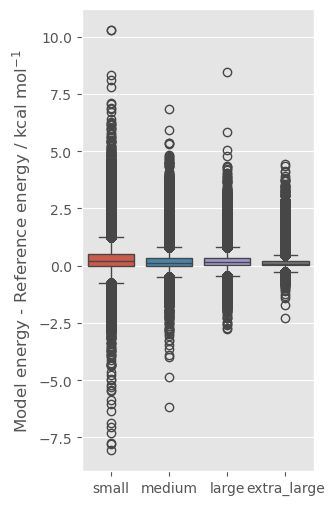

In [40]:
# Boxplots

fig, ax = plt.subplots(figsize=(3, 6))
sns.boxplot(data=[differences[model] for model in MACE_MODELS], ax=ax)
ax.set_xticklabels(MACE_MODELS)
ax.set_ylabel("Model energy - Reference energy / kcal mol$^{-1}$")
# fig.savefig("mace_off_box_plot.png", bbox_inches="tight", dpi=300)


In [154]:
energies_mace_all = []
for entry in tqdm(dataset_dimer):
    energies_mace = get_energy_mace(entry["smiles_a"],
                                    entry["smiles_b"],
                                    entry["coords"],
                                    model_name="small")
    energies_mace_all.append(energies_mace)

  0%|          | 0/6143 [00:00<?, ?it/s]/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this 

Using MACE-OFF23 MODEL for MACECalculator with /home/campus.ncl.ac.uk/nfc78/.cache/mace/MACE-OFF23_small.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head Default out of ['Default']


  0%|          | 1/6143 [00:00<1:14:53,  1.37it/s]/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relate

Using MACE-OFF23 MODEL for MACECalculator with /home/campus.ncl.ac.uk/nfc78/.cache/mace/MACE-OFF23_small.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head Default out of ['Default']


  0%|          | 2/6143 [00:01<1:15:12,  1.36it/s]/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relate

...

  1%|          | 39/6143 [00:26<1:15:23,  1.35it/s]/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relat

Using MACE-OFF23 MODEL for MACECalculator with /home/campus.ncl.ac.uk/nfc78/.cache/mace/MACE-OFF23_small.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head Default out of ['Default']


  1%|          | 40/6143 [00:27<1:16:44,  1.33it/s]/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relat

Using MACE-OFF23 MODEL for MACECalculator with /home/campus.ncl.ac.uk/nfc78/.cache/mace/MACE-OFF23_small.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head Default out of ['Default']


KeyboardInterrupt: 

Using MACE-OFF23 MODEL for MACECalculator with /home/campus.ncl.ac.uk/nfc78/.cache/mace/MACE-OFF23_small.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head Default out of ['Default']


/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

(-2.0, 2.0)

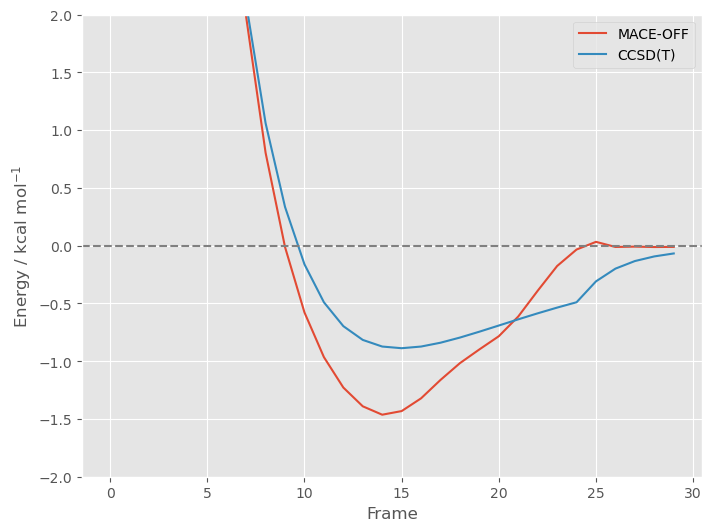

In [173]:
DIMER_IDX = 18  # Index of the dimer to test

energies_mace = get_energy_mace(dataset_dimer[DIMER_IDX]["smiles_a"],
                                dataset_dimer[DIMER_IDX]["smiles_b"],
                                dataset_dimer[DIMER_IDX]["coords"],
                                model_name="small")

energies_ccsdt = dataset_dimer[DIMER_IDX]["energy"].detach().cpu().numpy()

energies_mace = (energies_mace - energies_mace[-1])[:-1]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(energies_mace, label="MACE-OFF")
ax.plot(energies_ccsdt, label="CCSD(T)")
ax.set_xlabel("Frame")
ax.set_ylabel("Energy / kcal mol$^{-1}$")
# Horizontal line at 0
ax.axhline(0, color='gray', linestyle='--')
ax.legend()
ax.set_ylim(-2, 2)


In [105]:
energies_mace = get_energy_mace(dataset_dimer[1]["smiles_a"],
                dataset_dimer[1]["smiles_b"],
                dataset_dimer[1]["coords"],
                model_name="medium")

energies_ccsdt = da

Using MACE-OFF23 MODEL for MACECalculator with /home/campus.ncl.ac.uk/nfc78/.cache/mace/MACE-OFF23_medium.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/campus.ncl.ac.uk/nfc78/miniforge3/envs/des-lj/lib/python3.12/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

Using head Default out of ['Default']


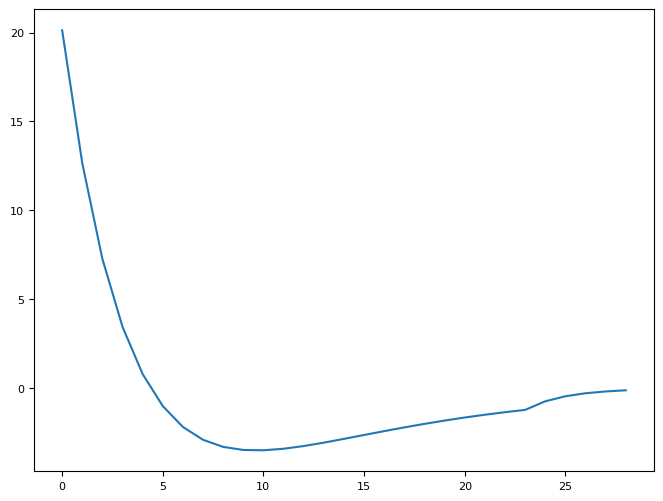

In [116]:
# Plot the energies
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# plt.plot(energies)
plt.plot(dataset_dimer[70]["energy"].detach().cpu().numpy())

In [81]:
# Evaluate the energies with an MM FF

def get_energy_mm(smiles_a: str,
                   smiles_b: str,
                   coords: torch.Tensor,
                   ff_name: str) -> torch.Tensor:
    """Evaluate the energies for a set of dimer coordinates using an OpenFF MM force field."""

    ff = ForceField(ff_name)
    
    # Get the molecules and OpenMM system
    mol_a = Molecule.from_mapped_smiles(smiles_a)
    mol_b = Molecule.from_mapped_smiles(smiles_b)
    omm_sys = ff.create_openmm_system([mol_a, mol_b])

    # Reshape the coordinates and convert to openmm vec3
    tot_atoms = mol_a.n_atoms + mol_b.n_atoms
    coords = coords.view(-1, tot_atoms, 3)
    coords = coords.cpu().detach().numpy()
    # Convert to openmm units with vec3, in angstrom
    coords = np.array([[openmm.Vec3(coord[0], coord[1], coord[2]) for coord in coord_set] for coord_set in coords])

    # Get the energies
    energies_mm = np.zeros((coords.shape[0]))
    for i, coord in enumerate(coords):
        energies = get_openmm_dimer_energies(omm_sys, coord, "CUDA")
        energies_kcal = [x.value_in_unit(openmm.unit.kilocalorie_per_mole) for x in energies.values()]
        energies_mm[i] = sum(energies_kcal)

    return torch.tensor(energies_mm, dtype=torch.float64)
    

In [82]:
sys[0].value_in_unit(openmm.unit.kilocalorie_per_mole)

-0.188476724788746

tensor([578859.9390, 578866.6380, 578857.9802, 578856.4324, 578868.1491,
        578860.6257, 578860.7502, 578858.7235, 578868.1092, 578846.0058,
        578857.9606, 578874.5759, 578857.9693, 578866.4582, 578874.8872,
        578866.7052, 578852.1296, 578869.9392, 578868.2099, 578858.6530,
        578866.6032, 578883.2769, 578858.0050, 578864.5805, 578870.2093,
        578855.4003, 578863.5337, 578857.5044, 578868.2041],
       dtype=torch.float64)

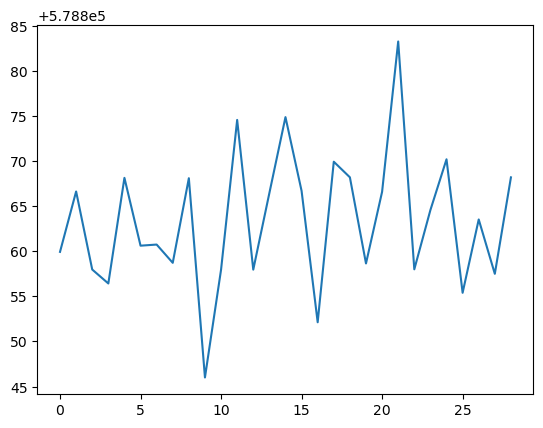

In [86]:
import matplotlib.pyplot as plt

plt.plot(range(len(sys)), sys)

sys

In [83]:
sys = get_energy_mm(dataset_dimer[0]["smiles_a"],
              dataset_dimer[0]["smiles_b"],
                dataset_dimer[0]["coords"],
                "openff-2.2.1.offxml")

In [ ]:
interchange = Interchange.from_smirnoff("openff"

In [38]:
test_mol = Molecule.from_smiles("C")
test_mol.generate_conformers(n_conformers=1)


In [19]:
dataset_dimer[0]

{'smiles_a': '[O:1]=[C:2]([N:3]([C:4]([H:7])([H:8])[H:9])[C:5]([H:10])([H:11])[H:12])[H:6]',
 'smiles_b': '[c:1]1([H:7])[c:2]([H:8])[c:3]([H:9])[c:4]([H:10])[c:5]([H:11])[c:6]1[H:12]',
 'coords': tensor([ 0.8417, -0.8267,  0.4918,  ...,  7.5153,  6.9767,  3.0327]),
 'energy': tensor([21.6535, 13.3841,  7.3709,  3.0765,  0.0775, -1.9548, -3.2748, -4.0760,
         -4.5056, -4.6740, -4.6625, -4.5319, -4.3260, -4.0758, -3.8040, -3.5255,
         -3.2508, -2.9867, -2.7371, -2.5042, -2.2889, -2.0913, -1.9107, -1.7464,
         -1.1288, -0.7534, -0.5209, -0.3722, -0.2736]),
 'source': 'DES370K system=15948 orig=370K group=1316474'}

In [41]:
test_mol.conformers[0].openmm

Magnitude,[[-6.580352783203125e-05 -6.139278411865234e-06 2.1517276763916016e-05] [-0.056671142578125 1.0869140625 -0.0859375] [0.61962890625 -0.397216796875 -0.80712890625] [-1.00390625 -0.423583984375 -0.069580078125] [0.441650390625 -0.2666015625 0.962890625]]
Units,angstrom


## Evaluate all the energies

## Analyse